In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [53]:
dirname = '/kaggle/input/titanic/'
train = pd.read_csv(dirname+'train.csv')
test = pd.read_csv(dirname+'test.csv')

train_x = train.drop(['Survived'], axis=1)
train_y = train['Survived']

test_x = test.copy()

In [54]:
#可視化手法
# 1. bar chart
# 2. box plot, violin plot
# 3. scatter plot
# 4. line chart
# 5. heat map
# 6. histogram
# 7. Q-Q plot
# 8. t-SNE, UMAP

In [55]:
train_x.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [56]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# bar chart

PassengerId


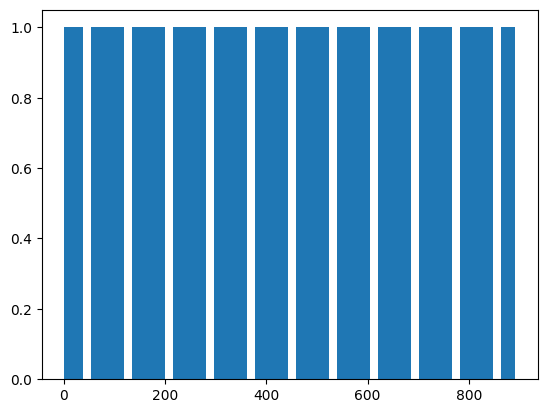

Pclass


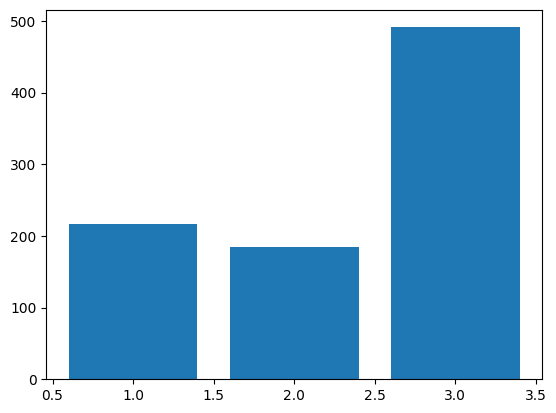

Name


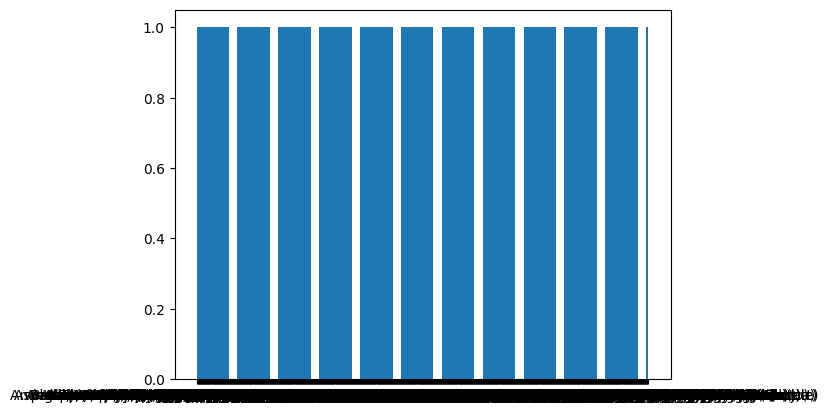

Sex


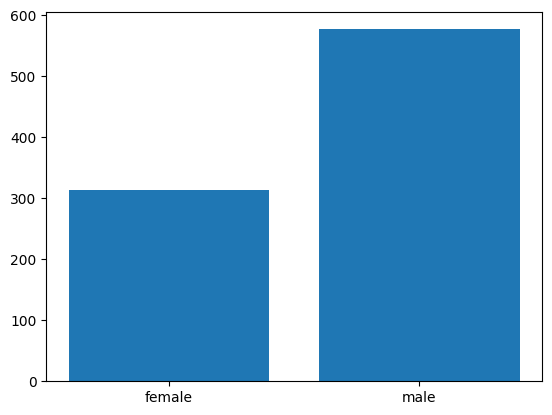

Age


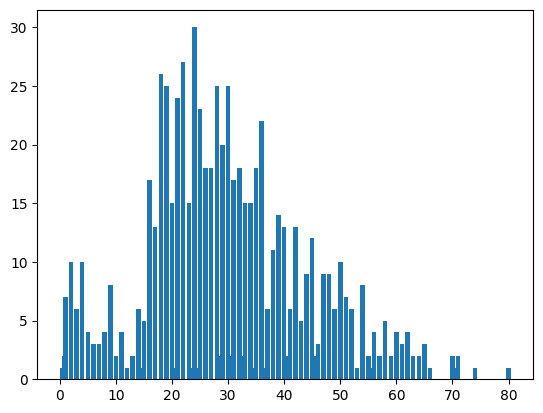

SibSp


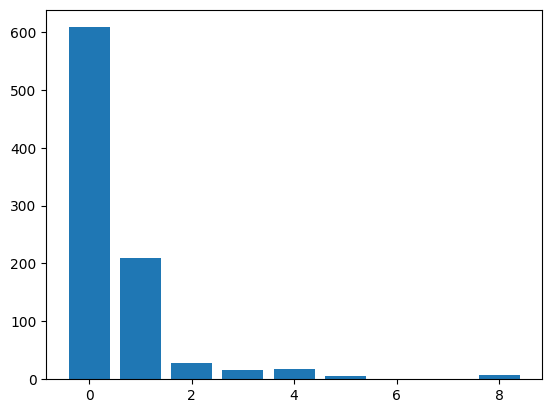

Parch


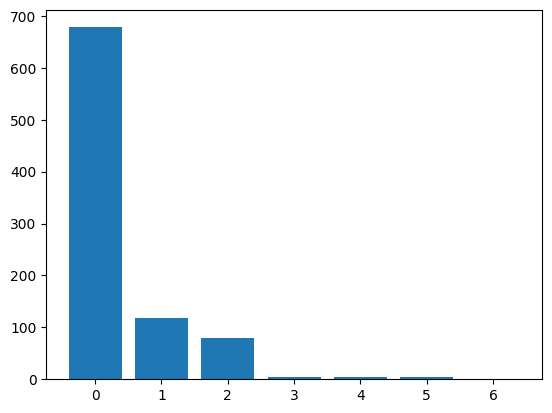

Ticket


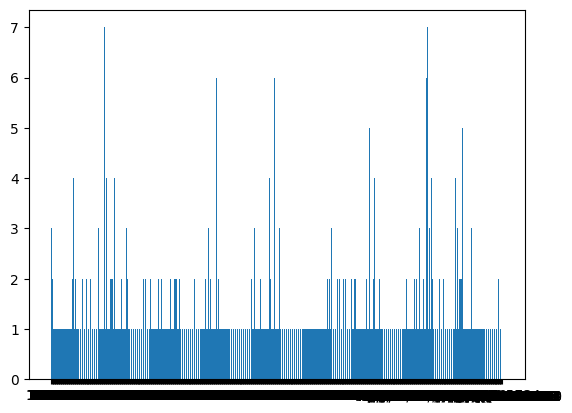

Fare


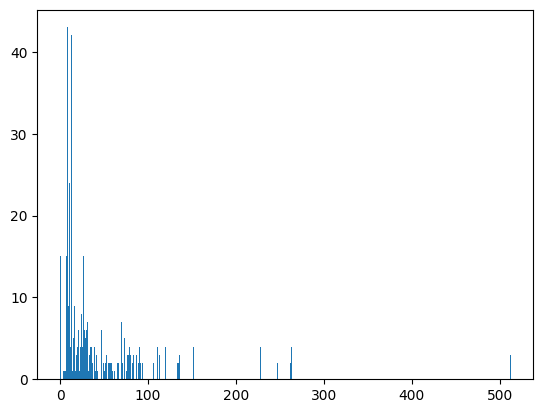

Cabin


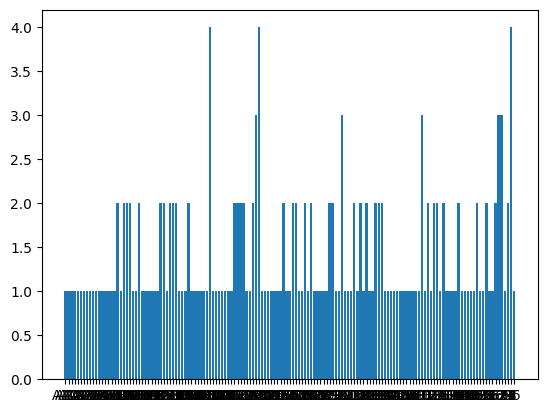

Embarked


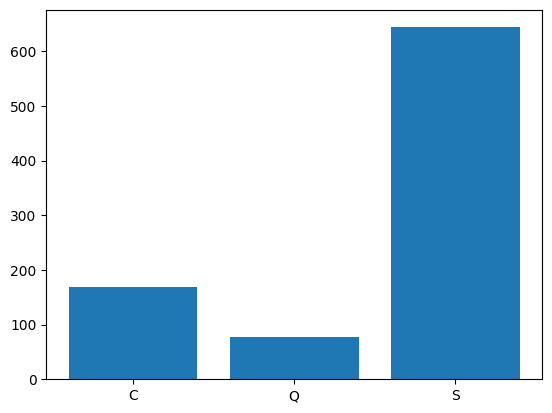

In [58]:
for col in train_x.columns:
    print(col)
    counts = train_x[col].value_counts()
    x = sorted(counts.keys())
    y = counts[x]
    plt.figure()
    plt.bar(x, y)
    plt.show()
    # break

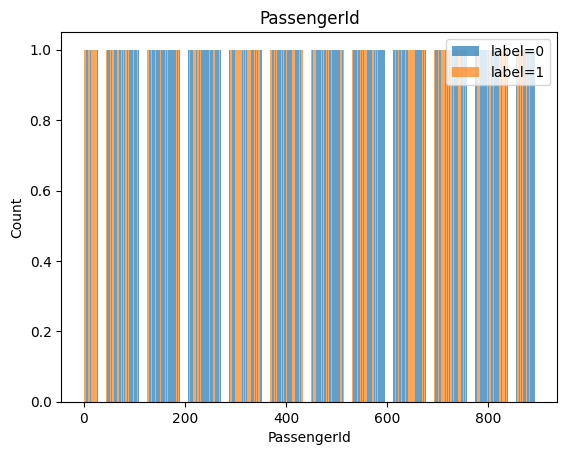

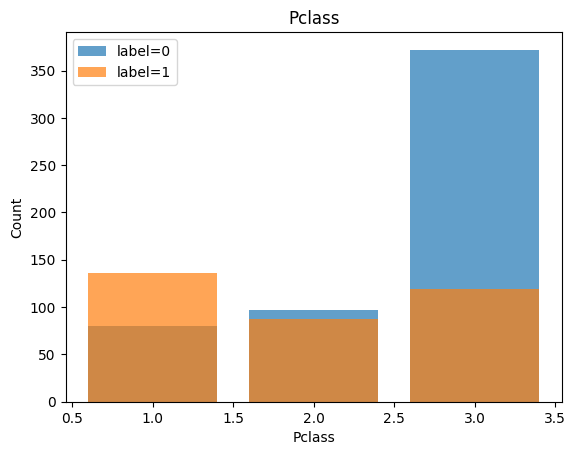

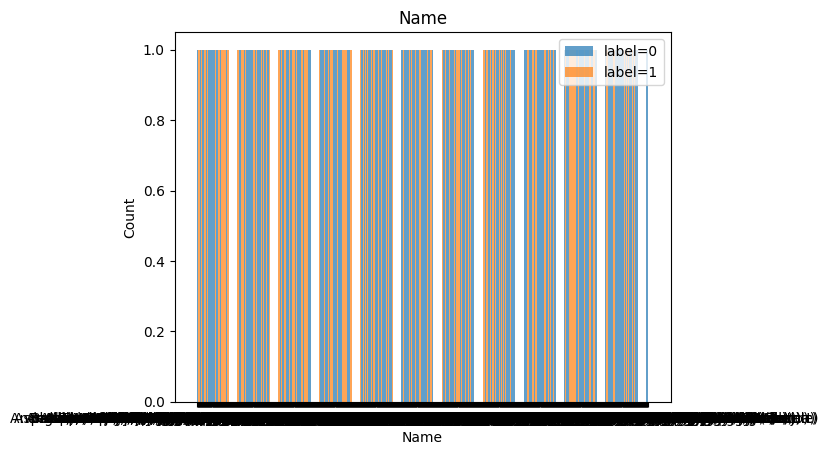

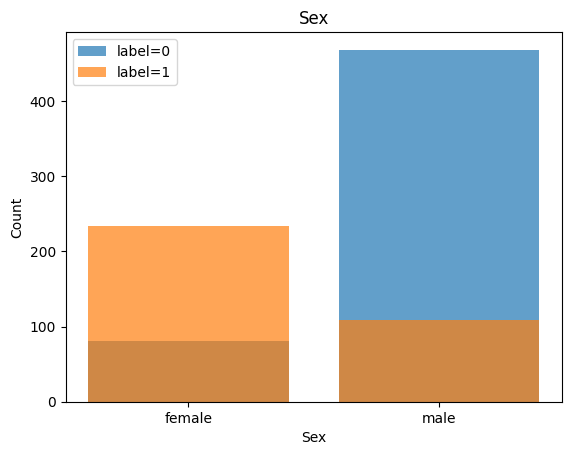

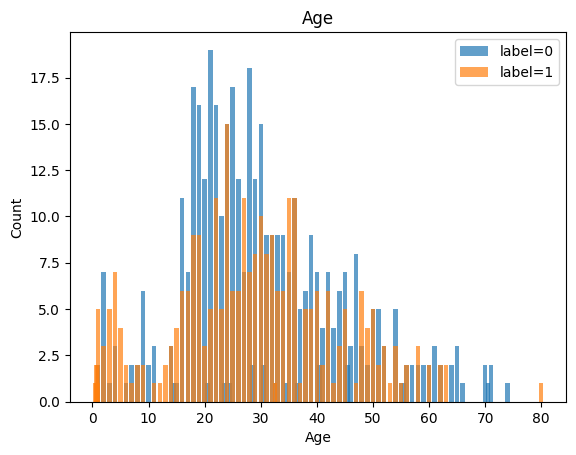

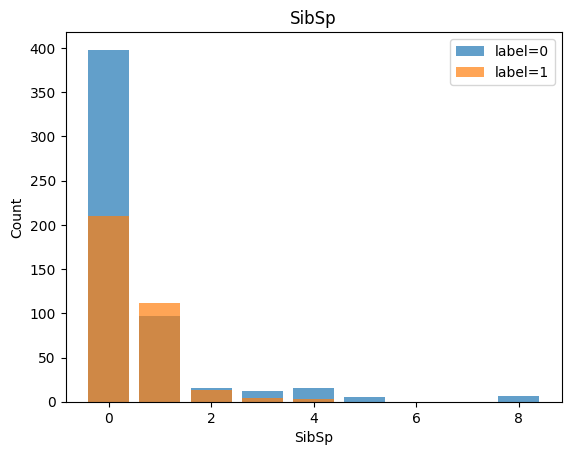

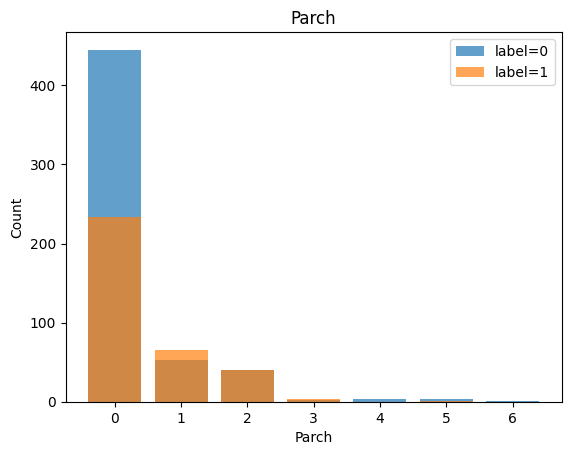

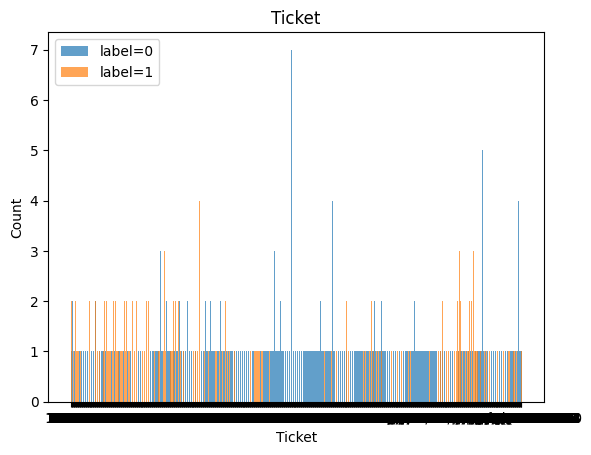

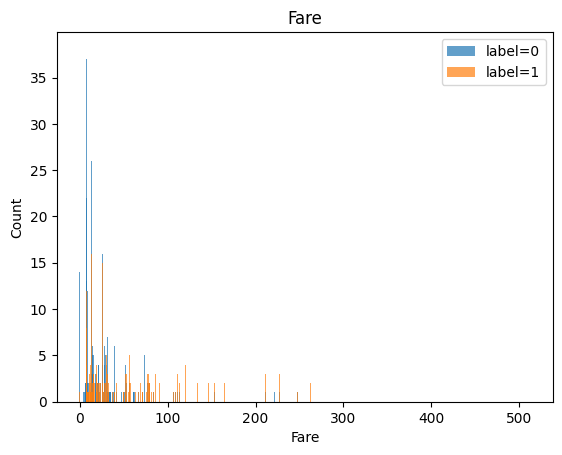

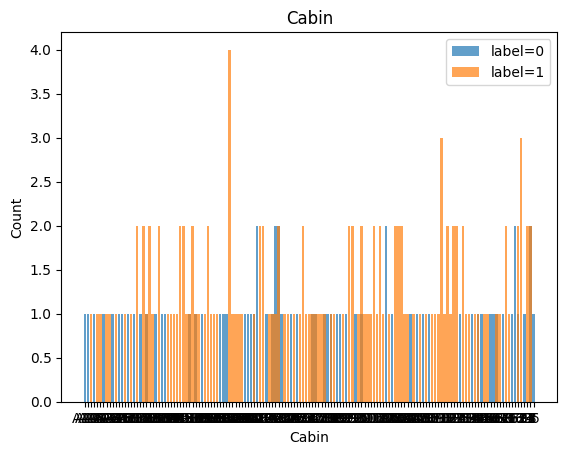

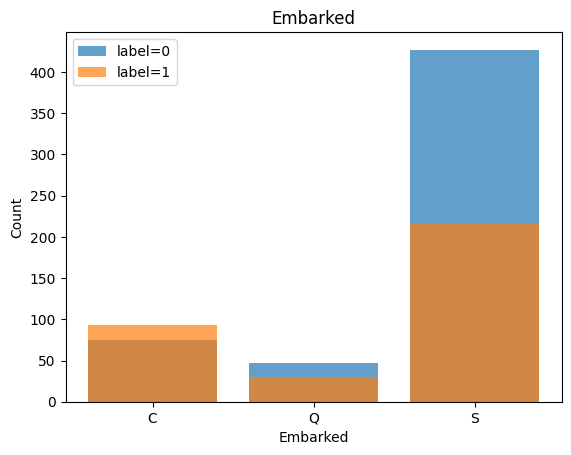

In [59]:
for col in train_x.columns:
    plt.figure()
    counts_0 = train_x[train_y==0][col].value_counts()
    counts_1 = train_x[train_y==1][col].value_counts()

    X = sorted(set(counts_0.index)|set(counts_1.index))
    y_0 = [counts_0.get(x, 0) for x in X]
    y_1 = [counts_1.get(x, 0) for x in X]
    plt.bar(X, y_0, label='label=0', alpha=0.7)
    plt.bar(X, y_1, label='label=1', alpha=0.7)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()


# histgram

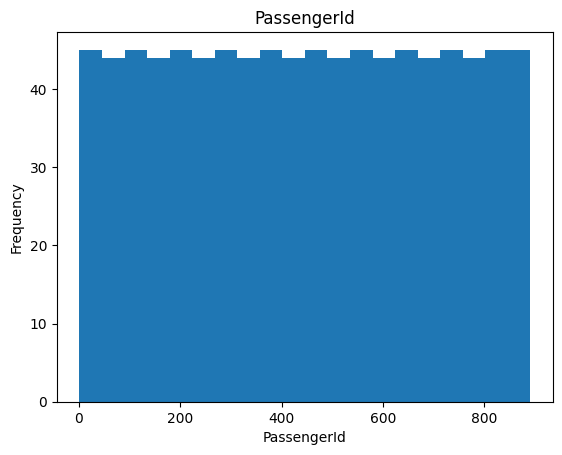

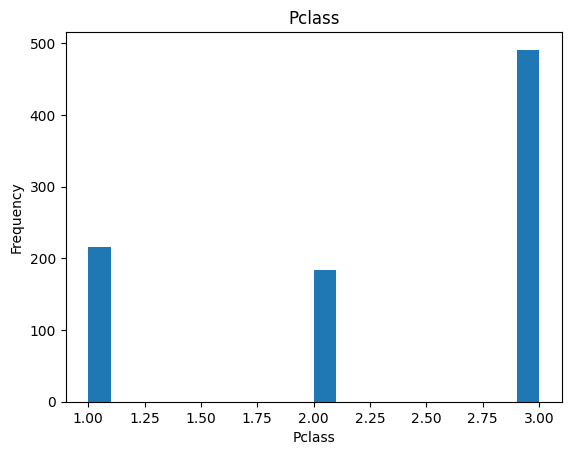

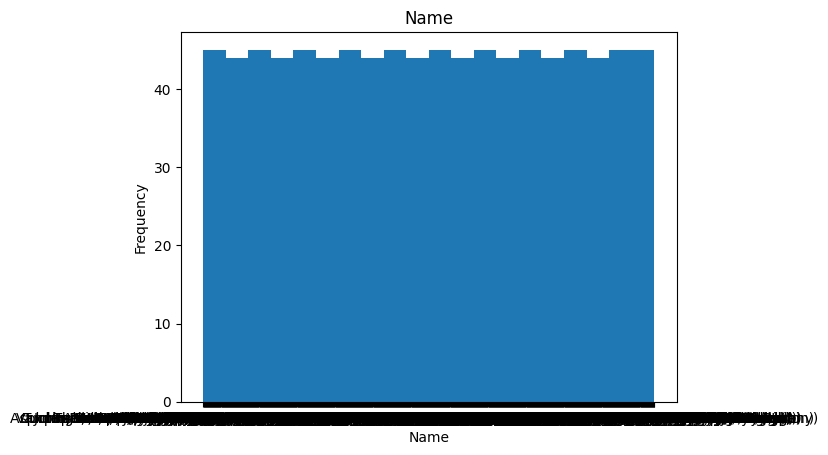

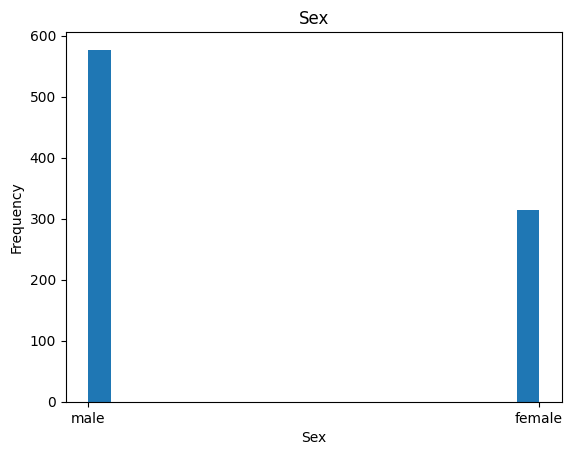

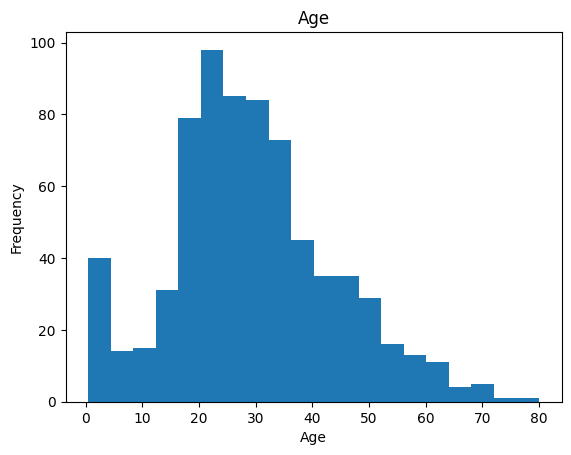

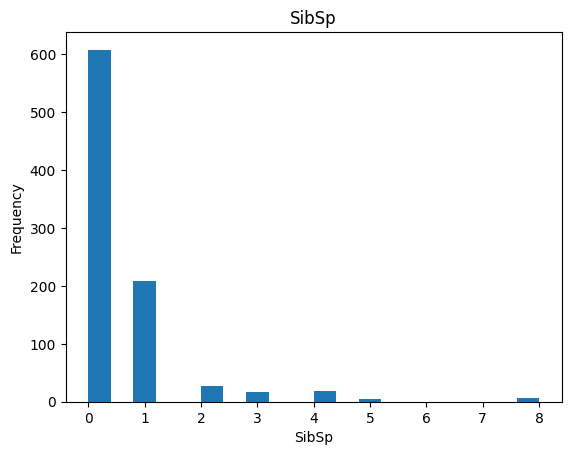

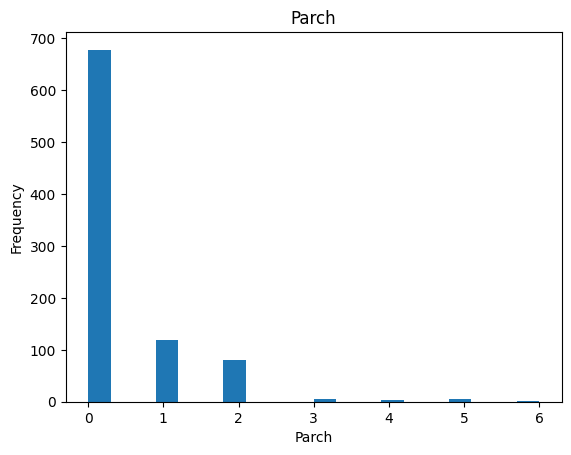

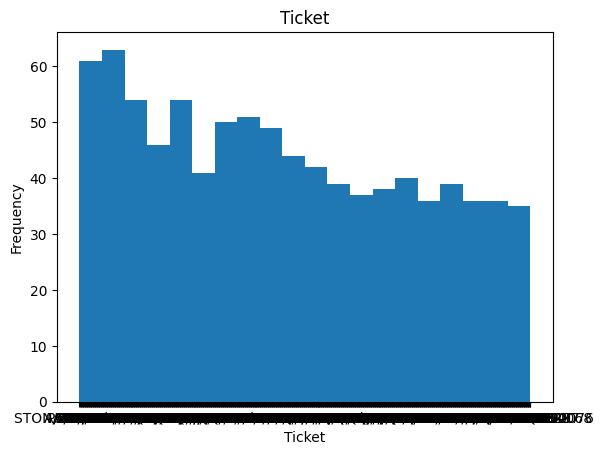

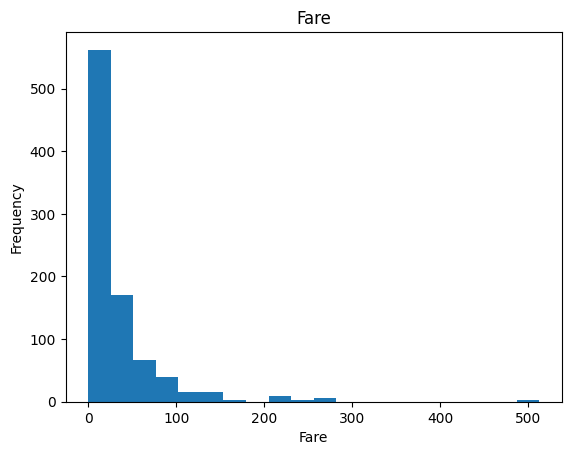

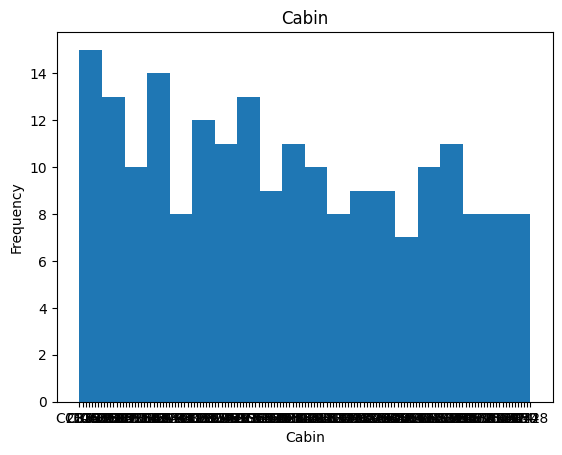

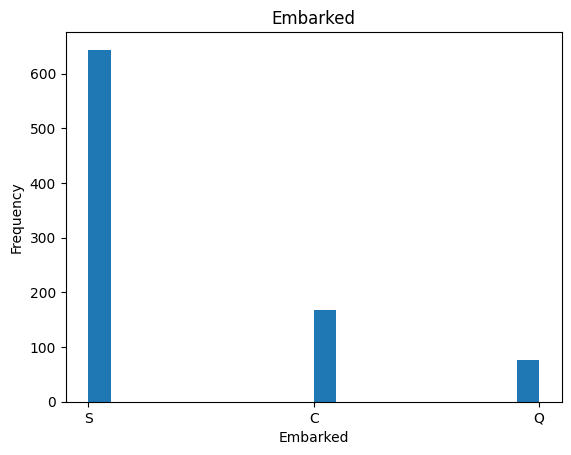

In [60]:
for col in train_x.columns:
    plt.figure()
    plt.hist(train_x[col].dropna(), bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')

In [61]:
train_x.Cabin

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

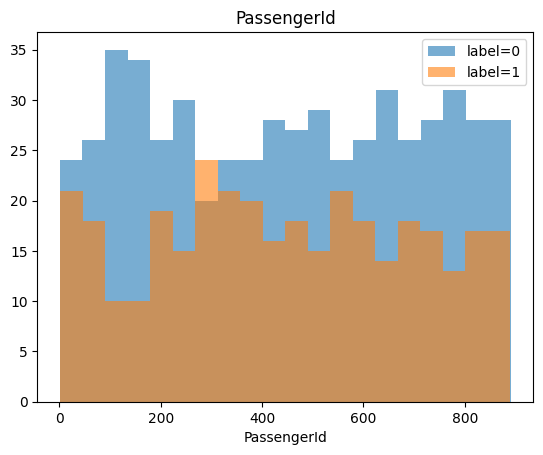

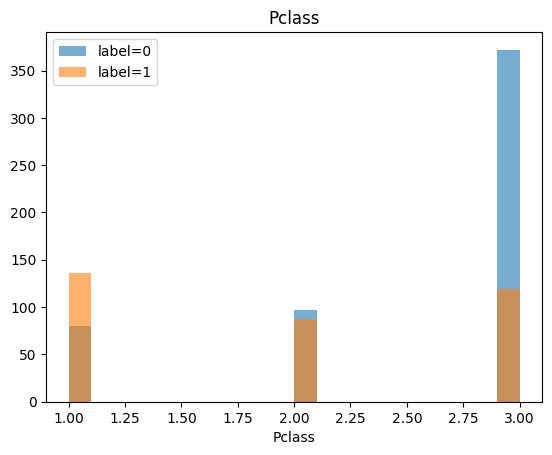

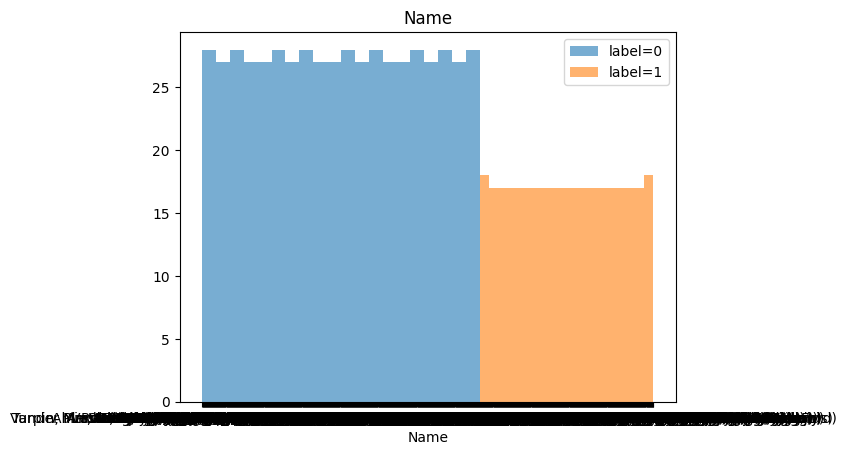

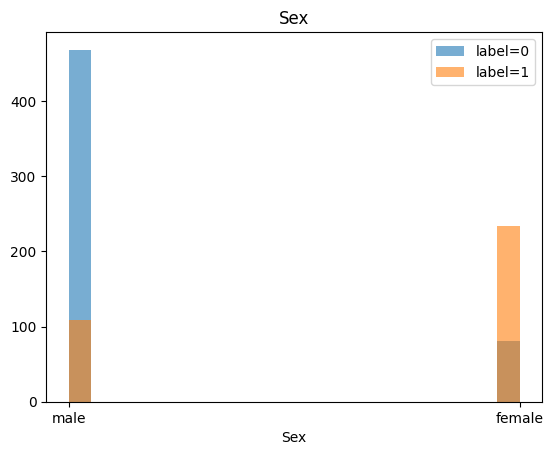

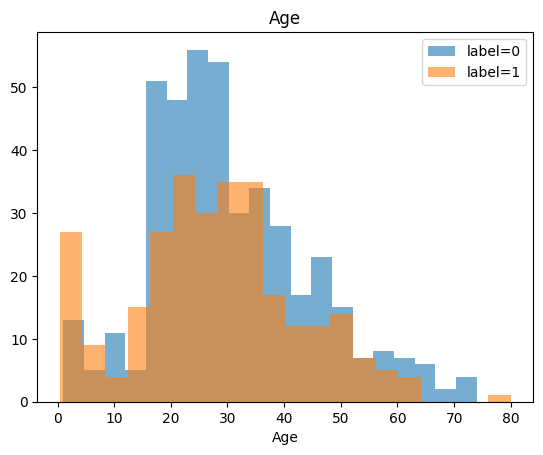

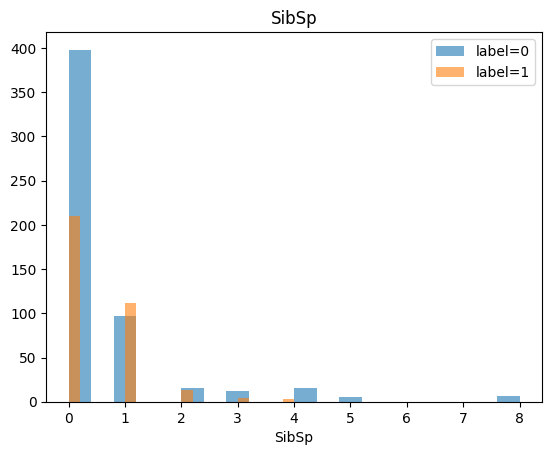

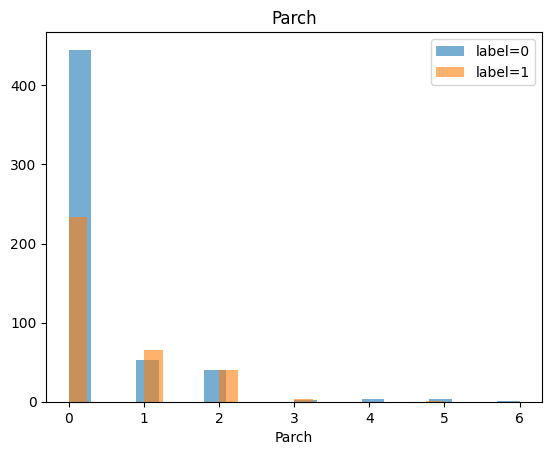

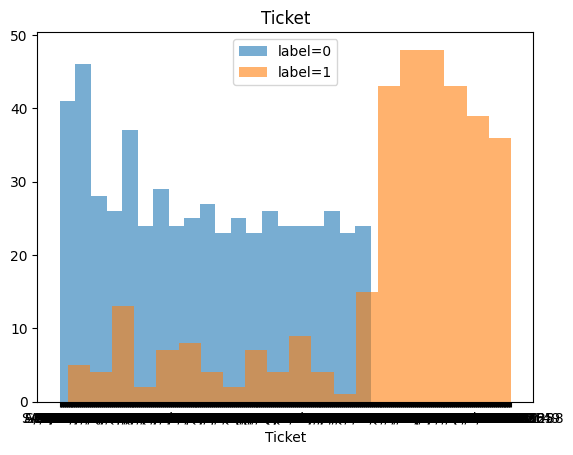

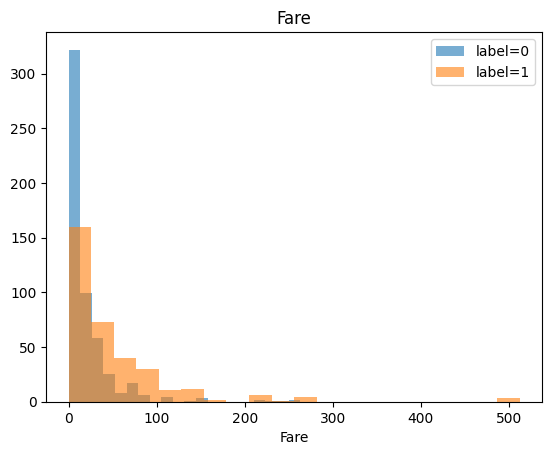

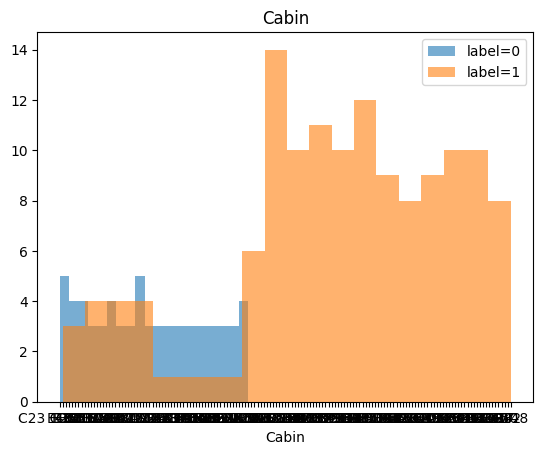

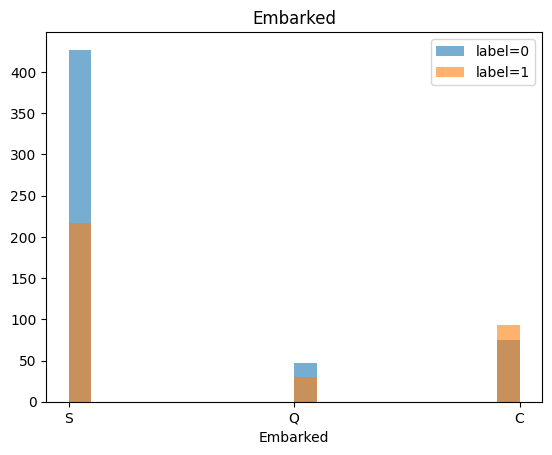

In [62]:
#すう

for col in train_x.columns:
    plt.figure()
    plt.hist(train_x[train_y==0][col].dropna(), bins=20, alpha=0.6, label='label=0')
    plt.hist(train_x[train_y==1][col].dropna(), bins=20, alpha=0.6, label='label=1')
    plt.title(col)
    plt.xlabel(col)
    plt.legend()


# box plot

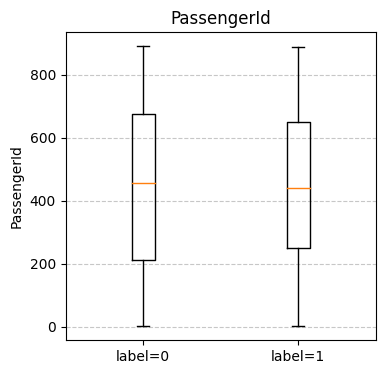

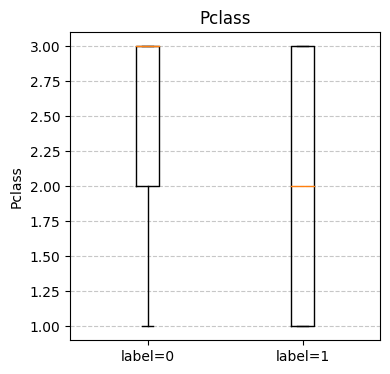

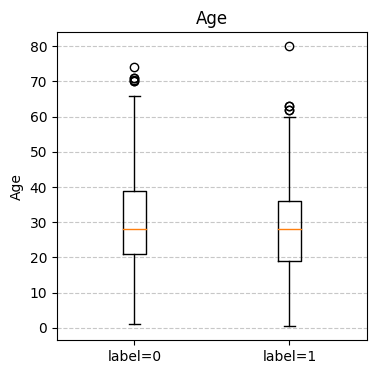

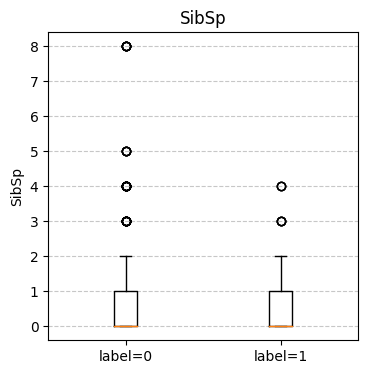

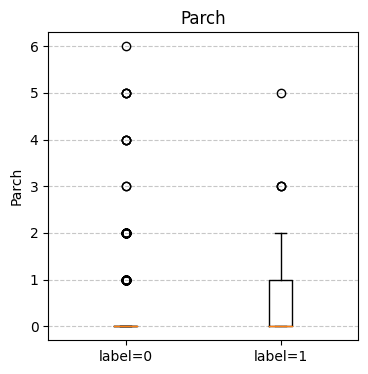

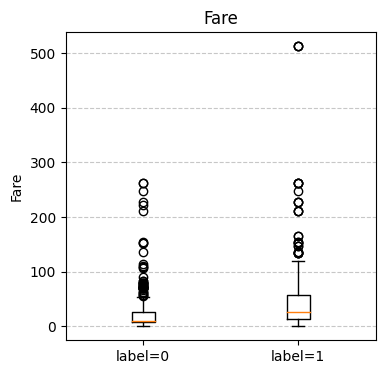

In [63]:
for col in train_x.columns:

    if not pd.api.types.is_numeric_dtype(train_x[col]):
        continue
        
    plt.figure(figsize=(4, 4))
    data = [
        train_x.loc[train_y==0, col].dropna(),
        train_x.loc[train_y==1, col].dropna()
    ]

    plt.boxplot(data, labels=['label=0', 'label=1'])
    plt.title(col)
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)


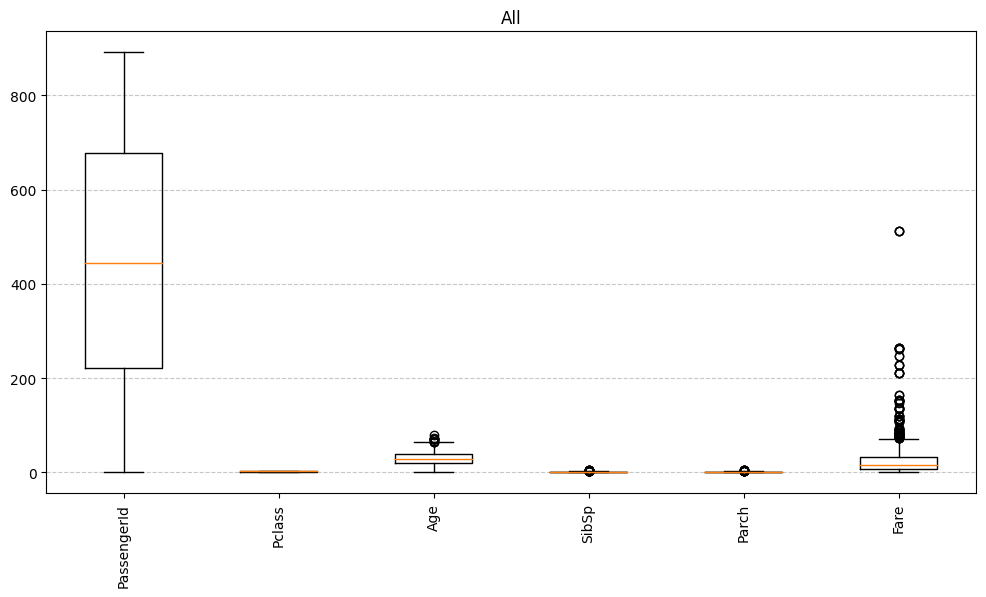

In [64]:
num_cols = train_x.select_dtypes(include='number').columns
plt.figure(figsize=(12, 6))
plt.boxplot(train_x[num_cols].dropna().values, labels=num_cols)
plt.xticks(rotation=90)
plt.title('All')
plt.grid(axis='y', linestyle='--', alpha=0.7)

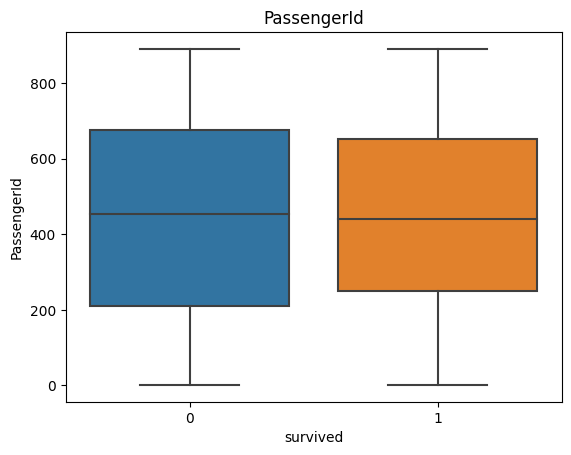

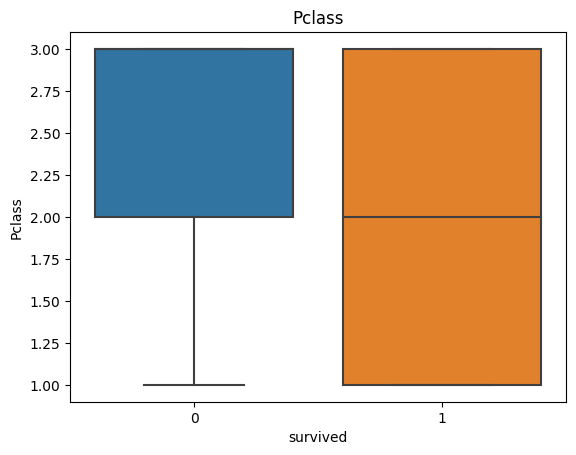

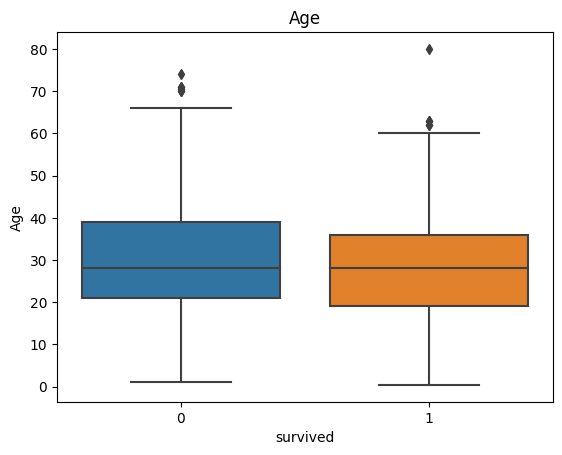

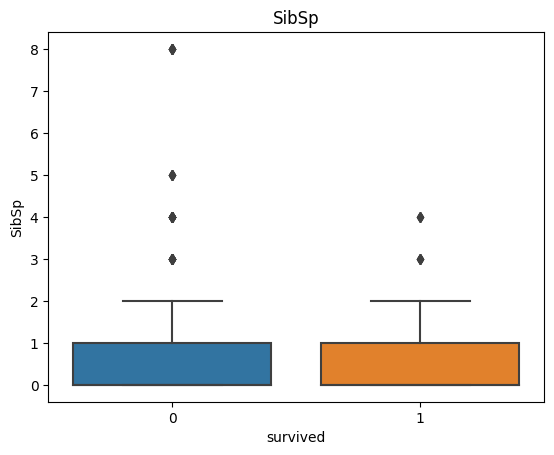

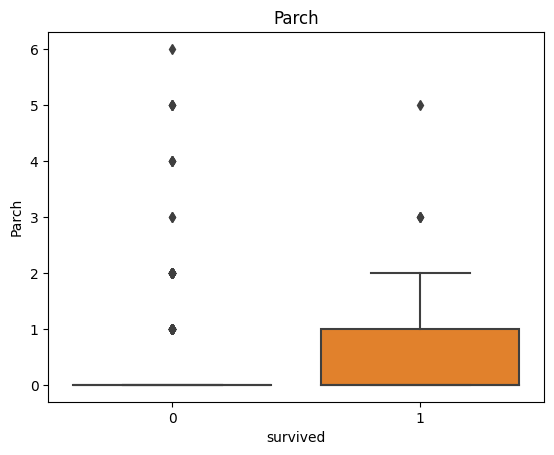

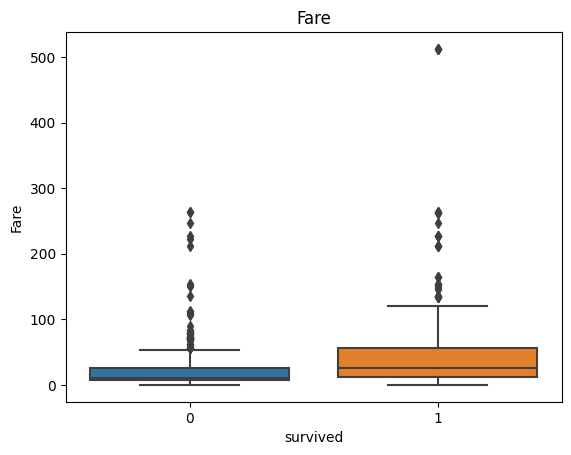

In [65]:
import seaborn as sns

for col in train_x.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=train_y, y=train_x[col])
    plt.title(col)
    plt.xlabel('survived')
    plt.ylabel(col)

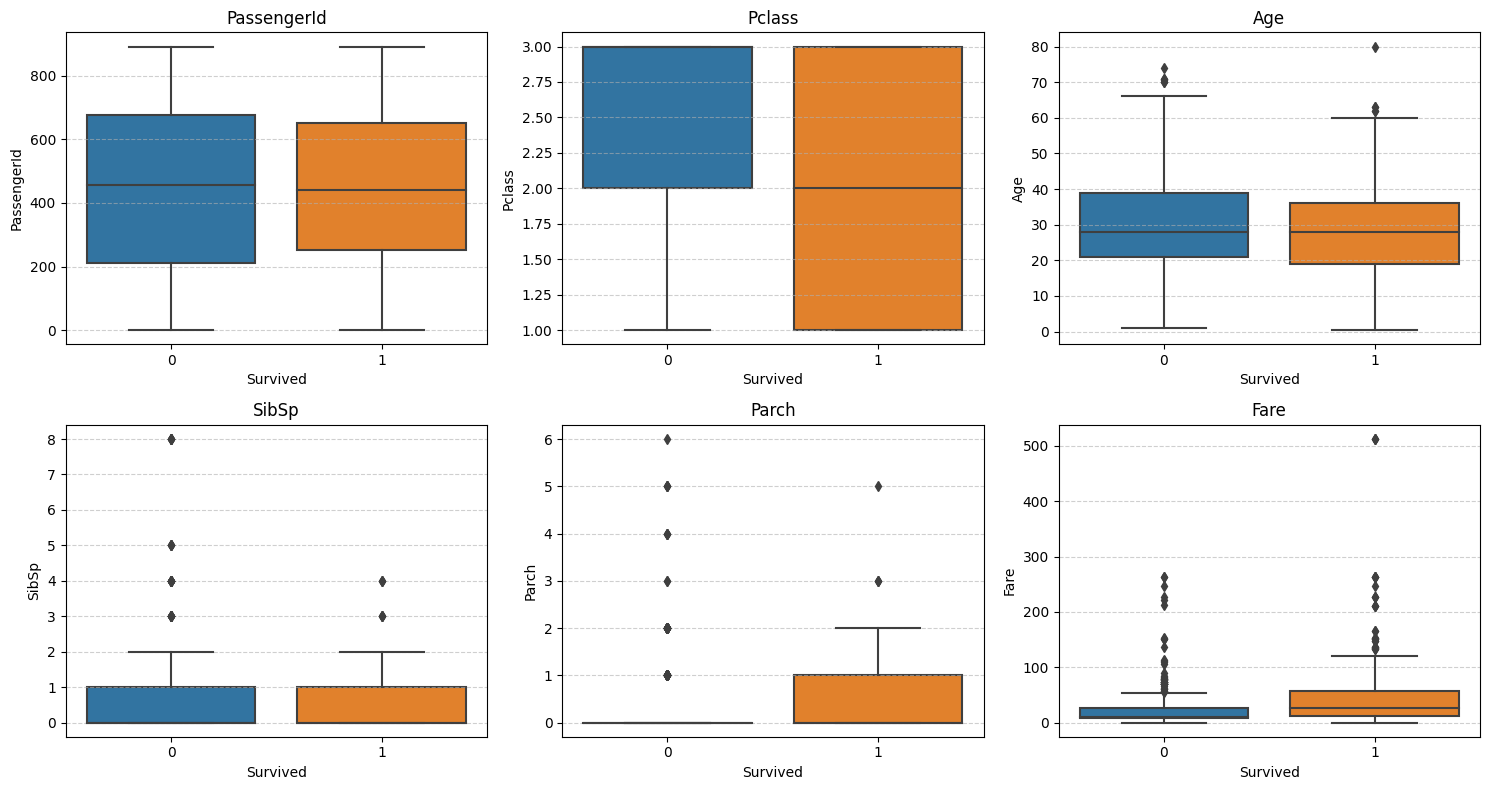

In [73]:
import math

num_cols = train_x.select_dtypes(include='number').columns
n_cols = len(num_cols)

n_per_row = 3
n_rows = math.ceil(n_cols / n_per_row)

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(15, 4*n_rows))
axes=axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # data = [
    #     train_x.loc[train_y==0, col].dropna(),
    #     train_x.loc[train_y==1, col].dropna()
    # ]
    # ax.boxplot(data, labels=['label=0', 'label=1'])
    sns.boxplot(x=train_y, y=train_x[col], ax=ax)
    ax.set_title(col)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

In [66]:
#可視化手法
# 1. bar chart
# 2. box plot, violin plot
# 3. scatter plot
# 4. line chart
# 5. heat map
# 6. histogram
# 7. Q-Q plot
# 8. t-SNE, UMAP